# <center><u>IPL Crunch '26: Data-Driven Analysis of Indian Premier League Matches</u></center>

**Author:** Paridhi Jain

**Competition:** IPL Crunch '26 by Wooble

### Objective
The Indian Premier League (IPL) generates massive amounts of ball-by-ball data every season. This project analyzes historical IPL match data to investigate whether common cricket assumptions are supported by evidence.

The analysis focuses on answering the following questions:
1. Do teams that win the toss actually win more matches?
2. Which phase of the innings has the greatest impact on victory:
   - Powerplay (Overs 1–6)
   - Middle Overs (Overs 7–15)
   - Death Overs (Overs 16–20)
3. Who are the top-performing batters and bowlers across IPL seasons?
4. What surprising insights can be discovered from the data?

The goal is to transform raw match data into meaningful insights using data cleaning, exploratory data analysis, visualization, and statistical reasoning.

### 1. Importing Required Libraries
Before performing any analysis, we import the Python libraries required for:
- Data manipulation
- JSON processing
- Visualization
- Statistical analysis

These libraries will be used throughout the project to process IPL match data and generate insights.

In [1]:
import pandas as pd
import numpy as np
import json
import zipfile
import os

import matplotlib.pyplot as plt
import seaborn as sns

print("Environment Ready")

Environment Ready


### 2. Loading and Extracting IPL Dataset
The IPL match data is provided as compressed JSON files.

Each JSON file represents a single IPL match and contains:
- Match metadata
- Toss information
- Match result
- Innings information
- Ball-by-ball deliveries

The dataset is extracted so that individual match files can be processed and combined into a single analytical dataset.

In [2]:
with zipfile.ZipFile("ipl_json.zip", "r") as zip_ref:
    zip_ref.extractall("ipl_data")

print("Dataset extracted successfully")

Dataset extracted successfully


### 3. Dataset Verification
Before processing the data, we verify that all match files have been successfully extracted.

This ensures:
- No missing files
- Successful extraction
- Reliable analysis in later stages

The total number of match files represents the number of IPL matches available for analysis.

In [3]:
json_files = []

for root, dirs, files in os.walk("ipl_data"):
    for file in files:
        if file.endswith(".json"):
            json_files.append(os.path.join(root, file))

print("Total JSON files:", len(json_files))

Total JSON files: 1239


### 4. Creating the Master Ball-by-Ball Dataset
The original dataset consists of 1,239 separate JSON files.

To perform large-scale analysis, these files are combined into a single master dataset where:
- Each row represents one delivery
- Each match contributes multiple rows
- Match-level and delivery-level information are preserved

Key variables collected include:
- Season
- Match Date
- Toss Winner
- Match Winner
- Batting Team
- Batter
- Bowler
- Runs Scored
- Wickets
- Over Number

This master dataset serves as the foundation for all subsequent analyses.

In [4]:
import json
import pandas as pd
from tqdm import tqdm

all_deliveries = []

for file_path in tqdm(json_files):

    try:
        with open(file_path, "r", encoding="utf-8") as f:
            match = json.load(f)

        info = match.get("info", {})

        winner = None
        if "outcome" in info and "winner" in info["outcome"]:
            winner = info["outcome"]["winner"]

        toss_winner = info.get("toss", {}).get("winner")

        match_date = None
        if "dates" in info:
            match_date = str(info["dates"][0])

        season = info.get("season")

        innings_list = match.get("innings", [])

        for innings_no, innings in enumerate(innings_list, start=1):

            team = innings.get("team")

            deliveries = innings.get("overs", [])

            for over_data in deliveries:

                over_number = over_data.get("over")

                for ball in over_data.get("deliveries", []):

                    batter = ball.get("batter")
                    bowler = ball.get("bowler")

                    runs_batter = ball.get("runs", {}).get("batter", 0)
                    runs_total = ball.get("runs", {}).get("total", 0)

                    wicket = 1 if "wickets" in ball else 0

                    all_deliveries.append({
                        "season": season,
                        "date": match_date,
                        "innings": innings_no,
                        "batting_team": team,
                        "winner": winner,
                        "toss_winner": toss_winner,
                        "over": over_number,
                        "batter": batter,
                        "bowler": bowler,
                        "batter_runs": runs_batter,
                        "total_runs": runs_total,
                        "wicket": wicket
                    })

    except Exception as e:
        print("Error:", file_path)

df = pd.DataFrame(all_deliveries)

print(df.shape)
df.head()

100%|█████████████████████████████████████████████████████████████████████████████| 1239/1239 [00:04<00:00, 297.47it/s]


(294757, 12)


,season,date,innings,batting_team,winner,toss_winner,over,batter,bowler,batter_runs,total_runs,wicket
0,2017,2017-04-05,1,Sunrisers Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,0,DA Warner,TS Mills,0,0,0
1,2017,2017-04-05,1,Sunrisers Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,0,DA Warner,TS Mills,0,0,0
2,2017,2017-04-05,1,Sunrisers Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,0,DA Warner,TS Mills,4,4,0
3,2017,2017-04-05,1,Sunrisers Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,0,DA Warner,TS Mills,0,0,0
4,2017,2017-04-05,1,Sunrisers Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,0,DA Warner,TS Mills,0,2,0


### 5. Dataset Overview
After processing all IPL match files, a consolidated ball-by-ball dataset was created.

This dataset contains every recorded delivery available in the provided IPL history.

The resulting dataset enables:
- Match outcome analysis
- Toss impact analysis
- Phase-wise scoring analysis
- Batter performance analysis
- Bowler performance analysis

The next sections use this dataset to answer the challenge questions through data-driven evidence.

## 6. Does Winning the Toss Increase the Chances of Winning the Match?
One of the most common beliefs in cricket is that winning the toss provides a significant advantage.

Factors such as pitch conditions, dew, weather, and match strategy often influence the decision to bat or bowl first.

This analysis investigates whether teams that win the toss also tend to win the match more frequently.

**Methodology:**

For each IPL match:
- Identify the toss winner
- Identify the match winner
- Compare both outcomes

If the toss winner also won the match, it is counted as a successful toss outcome.

The overall percentage is then calculated across all matches.

In [5]:
matches = df[['date', 'winner', 'toss_winner']].drop_duplicates()

matches['toss_winner_won_match'] = (
    matches['winner'] == matches['toss_winner']
)

matches.head()

,date,winner,toss_winner,toss_winner_won_match
0,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,False
248,2017-04-06,Rising Pune Supergiant,Rising Pune Supergiant,True
495,2017-04-07,Kolkata Knight Riders,Kolkata Knight Riders,True
713,2017-04-08,Kings XI Punjab,Kings XI Punjab,True
960,2017-04-08,Royal Challengers Bangalore,Royal Challengers Bangalore,True


In [6]:
toss_won = matches['toss_winner_won_match'].sum()
total_matches = len(matches)

toss_win_rate = (toss_won / total_matches) * 100

print(f"Total Matches: {total_matches}")
print(f"Matches Won By Toss Winner: {toss_won}")
print(f"Toss Winner Match Win Rate: {toss_win_rate:.2f}%")

Total Matches: 1239
Matches Won By Toss Winner: 627
Toss Winner Match Win Rate: 50.61%


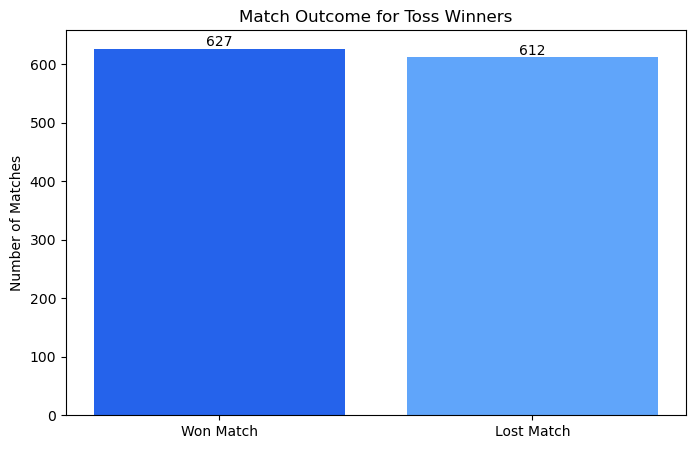

In [21]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    ['Won Match', 'Lost Match'],
    [toss_won, total_matches - toss_won],
    color=['#2563EB', '#60A5FA']
)

plt.title('Match Outcome for Toss Winners')
plt.ylabel('Number of Matches')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f'{int(height)}',
        ha='center'
    )

plt.savefig(
    'chart_1_toss_impact.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

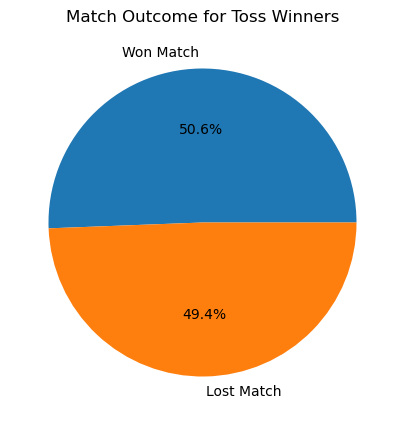

In [10]:
plt.figure(figsize=(5,5))

plt.pie(
    [toss_won, total_matches - toss_won],
    labels=['Won Match', 'Lost Match'],
    autopct='%1.1f%%'
)

plt.title('Match Outcome for Toss Winners')

plt.savefig(
    'toss_impact_pie.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<u>**Key Finding:**</u>
Across 1,239 IPL matches, teams that won the toss won the match only 50.61% of the time.

This suggests that the toss provides little to no significant advantage in determining match outcomes. While winning the toss may influence strategic decisions, overall team performance during the match remains the dominant factor behind victory.

<u>**Insight:**</u>
One of the most surprising findings is that the toss advantage is almost negligible. Despite widespread belief among fans and commentators, IPL data shows that toss winners and toss losers have nearly equal chances of winning.

## 7. Which Phase of the Innings Has the Greatest Impact on Victory?
A T20 innings can be divided into three phases:
1. Powerplay (Overs 1–6)
2. Middle Overs (Overs 7–15)
3. Death Overs (Overs 16–20)

Different phases demand different strategies. Teams often attack aggressively during the powerplay, consolidate during the middle overs, and accelerate during the death overs.

This analysis investigates which phase contributes most strongly to winning matches.

In [13]:
def phase(over):

    if over <= 5:
        return "Powerplay"

    elif over <= 14:
        return "Middle Overs"

    else:
        return "Death Overs"


df["phase"] = df["over"].apply(phase)

df[["over", "phase"]].head()

,over,phase
0,0,Powerplay
1,0,Powerplay
2,0,Powerplay
3,0,Powerplay
4,0,Powerplay


In [14]:
df["match_id"] = (
    df["date"].astype(str) +
    "_" +
    df["batting_team"].astype(str)
)

In [15]:
phase_runs = (
    df.groupby(
        [
            "match_id",
            "batting_team",
            "winner",
            "phase"
        ]
    )["total_runs"]
    .sum()
    .reset_index()
)

phase_runs.head()

,match_id,batting_team,winner,phase,total_runs
0,2008-04-18_Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Death Overs,68
1,2008-04-18_Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Middle Overs,93
2,2008-04-18_Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Powerplay,61
3,2008-04-18_Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Death Overs,1
4,2008-04-18_Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Middle Overs,55


In [16]:
phase_runs["result"] = np.where(
    phase_runs["batting_team"] == phase_runs["winner"],
    "Winner",
    "Loser"
)

phase_runs.head()

,match_id,batting_team,winner,phase,total_runs,result
0,2008-04-18_Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Death Overs,68,Winner
1,2008-04-18_Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Middle Overs,93,Winner
2,2008-04-18_Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Powerplay,61,Winner
3,2008-04-18_Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Death Overs,1,Loser
4,2008-04-18_Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Middle Overs,55,Loser


In [17]:
phase_summary = (
    phase_runs.groupby(
        ["phase", "result"]
    )["total_runs"]
    .mean()
    .reset_index()
)

phase_summary

,phase,result,total_runs
0,Death Overs,Loser,43.259478
1,Death Overs,Winner,47.379893
2,Middle Overs,Loser,66.755153
3,Middle Overs,Winner,74.579470
4,Powerplay,Loser,45.547776
5,Powerplay,Winner,51.460461


### Comparing Winners and Losers
To identify which phase has the strongest relationship with winning, we calculate the average run difference between winning teams and losing teams in each phase.

A larger difference indicates that the phase contributes more strongly to match outcomes.

In [22]:
phase_pivot = phase_summary.pivot(
    index='phase',
    columns='result',
    values='total_runs'
)

phase_pivot['Difference'] = (
    phase_pivot['Winner'] -
    phase_pivot['Loser']
)

phase_pivot = phase_pivot.sort_values(
    'Difference',
    ascending=False
)

phase_pivot

result,Loser,Winner,Difference
phase,,,
Middle Overs,66.755153,74.579470,7.824318
Powerplay,45.547776,51.460461,5.912685
Death Overs,43.259478,47.379893,4.120416


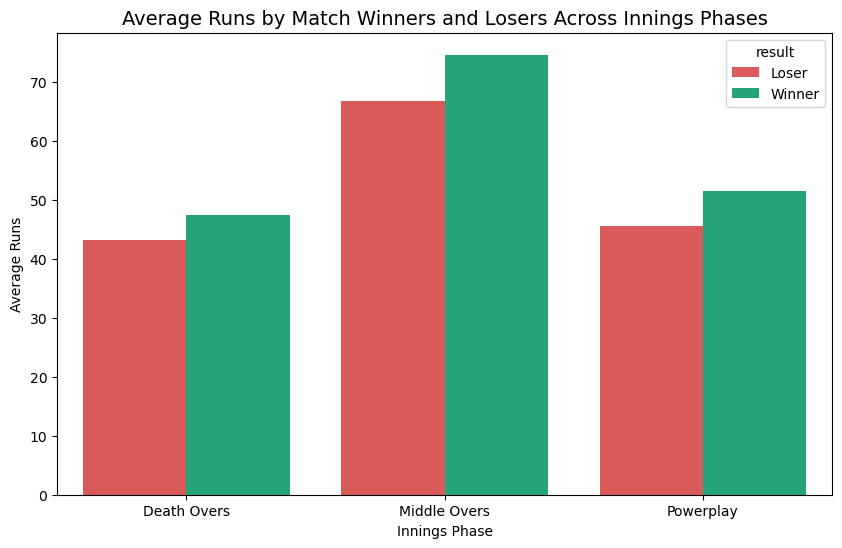

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=phase_summary,
    x='phase',
    y='total_runs',
    hue='result',
    palette=['#EF4444', '#10B981']
)

plt.title(
    'Average Runs by Match Winners and Losers Across Innings Phases',
    fontsize=14
)

plt.xlabel('Innings Phase')
plt.ylabel('Average Runs')

plt.savefig(
    'chart_2_phase_analysis.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<u>**Results:**</u>

Average runs scored by winning teams exceed those of losing teams in all three innings phases.

The largest gap occurs during the Middle Overs, where winning teams score approximately 7.82 more runs on average than losing teams.

This difference is greater than the gaps observed during both the Powerplay and Death Overs.

<u>**Key Insight:**</u>

Contrary to popular belief, the Death Overs are not the strongest indicator of victory.

The analysis shows that Middle Overs create the largest separation between winning and losing teams.

Teams that maintain scoring momentum during overs 7–15 are significantly more likely to win matches than teams that rely primarily on late-innings acceleration.

<u>**Surprising Finding:**</u>

While commentators often focus on explosive finishing in the Death Overs, IPL data suggests that matches are more frequently won through sustained dominance in the Middle Overs.

## 8. Top 5 Batters Across IPL Seasons
Batting performance is one of the most important determinants of success in T20 cricket.

This analysis identifies the highest run-scorers across the IPL dataset and highlights the players who have consistently contributed the most runs.

In [24]:
top_batters = (
    df.groupby('batter')['batter_runs']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_batters = top_batters.head(5)

top_batters

,batter,batter_runs
0,V Kohli,9228
1,RG Sharma,7331
2,S Dhawan,6769
3,DA Warner,6567
4,KL Rahul,5828


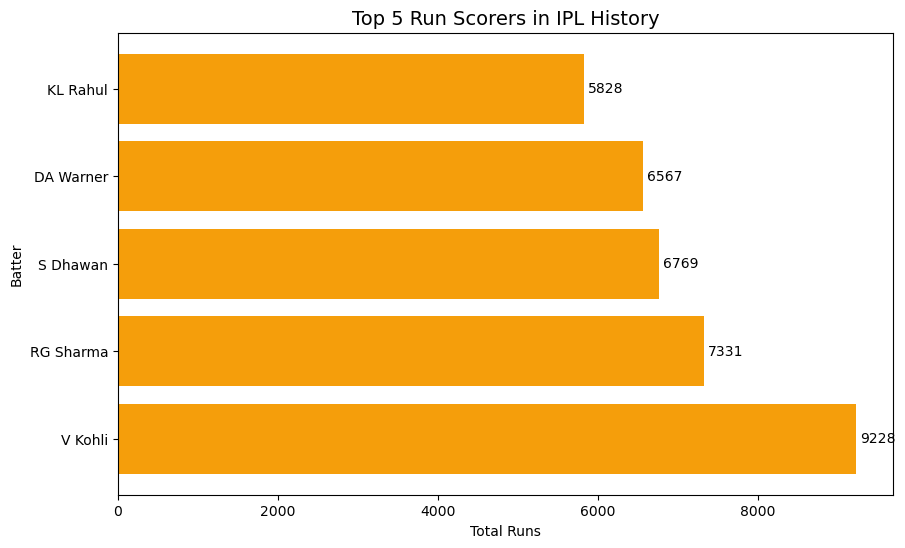

In [25]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    top_batters['batter'],
    top_batters['batter_runs'],
    color='#F59E0B'
)

plt.title(
    'Top 5 Run Scorers in IPL History',
    fontsize=14
)

plt.xlabel('Total Runs')
plt.ylabel('Batter')

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 50,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center'
    )

plt.savefig(
    'chart_3_top_batters.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<u>**Results:**</u>

Virat Kohli is the highest run-scorer in IPL history with 9,228 runs.

He is followed by Rohit Sharma, Shikhar Dhawan, David Warner, and KL Rahul.

The rankings highlight players who have demonstrated exceptional consistency and longevity across multiple IPL seasons.

<u>**Key Insight:**</u>

Virat Kohli has established a substantial lead over every other batter in the dataset.

His run tally exceeds 9,000 runs, reflecting both long-term consistency and sustained performance at the highest level of T20 cricket.

## 9. Top 5 Bowlers Across IPL Seasons
Wickets are one of the most valuable resources in T20 cricket.

This analysis identifies the bowlers who have taken the most wickets across IPL history and evaluates long-term bowling performance.

In [26]:
top_bowlers = (
    df.groupby('bowler')['wicket']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_bowlers = top_bowlers.head(5)

top_bowlers

,bowler,wicket
0,YS Chahal,242
1,B Kumar,239
2,SP Narine,229
3,JJ Bumrah,208
4,DJ Bravo,207


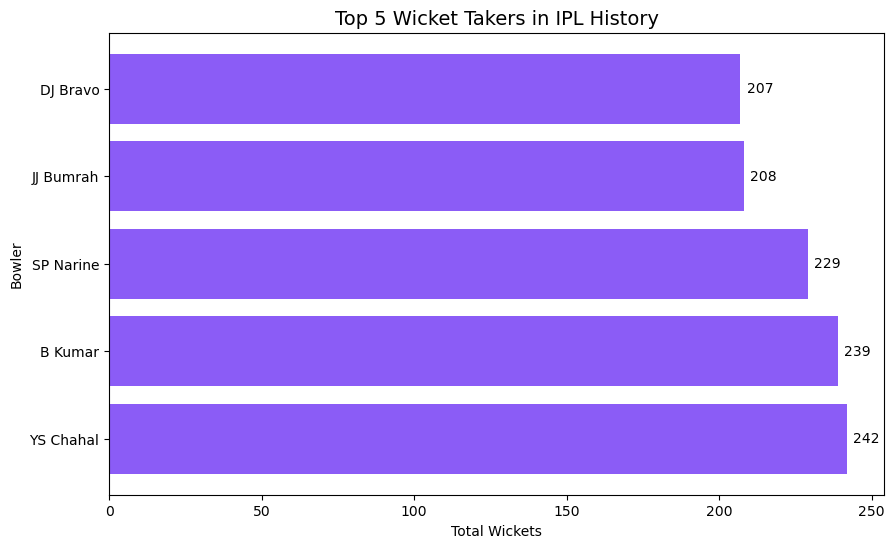

In [27]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    top_bowlers['bowler'],
    top_bowlers['wicket'],
    color='#8B5CF6'
)

plt.title(
    'Top 5 Wicket Takers in IPL History',
    fontsize=14
)

plt.xlabel('Total Wickets')
plt.ylabel('Bowler')

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center'
    )

plt.savefig(
    'chart_4_top_bowlers.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<u>**Results:**</u>

Yuzvendra Chahal leads the IPL wicket-taking charts with 242 wickets.

He is closely followed by Bhuvneshwar Kumar and Sunil Narine, both of whom have consistently performed across multiple IPL seasons.

The rankings highlight bowlers who have maintained effectiveness and longevity in a batting-dominated format.

<u>**Key Insight:**</u>

The difference between the top three wicket-takers is relatively small, indicating sustained competition among elite IPL bowlers.

Yuzvendra Chahal's position at the top demonstrates the long-term value of wicket-taking spinners in T20 cricket.

## 10. Most Surprising Finding

<u>**Finding:**</u>

Contrary to popular cricket opinion, the Death Overs are not the strongest indicator of winning IPL matches.

The largest scoring gap between winning and losing teams occurs during the Middle Overs:

- Middle Overs Difference: 7.82 runs
- Powerplay Difference: 5.91 runs
- Death Overs Difference: 4.12 runs

<u>**Why This Matters:**</u>

Cricket discussions often focus on explosive batting during the final overs of an innings.

However, IPL data suggests that teams gain a greater competitive advantage through sustained scoring and control during overs 7–15.

This indicates that Middle Overs may be the most underrated phase in T20 cricket.

## 11. Conclusion
This analysis examined historical IPL ball-by-ball data to evaluate common cricket assumptions and identify performance patterns.

Key findings include:

1. Winning the toss has minimal impact on match outcomes, with toss winners winning only 50.61% of matches.

2. The Middle Overs show the strongest relationship with winning, producing the largest scoring gap between successful and unsuccessful teams.

3. Virat Kohli is the leading run-scorer in the dataset with 9,228 runs.

4. Yuzvendra Chahal is the leading wicket-taker with 242 wickets.

Overall, the analysis demonstrates how data-driven investigation can challenge conventional assumptions and reveal deeper insights into cricket performance.

##### <u><Appendix: Additional Analysis></u>
## 12. Does Toss Advantage Change Across IPL Seasons?
While overall toss advantage appears minimal, it is possible that certain IPL seasons experienced a stronger or weaker toss effect.

This analysis evaluates the toss winner's match win rate across different seasons to identify long-term trends and variations.

In [29]:
season_matches = (
    df[['season', 'date', 'winner', 'toss_winner']]
    .drop_duplicates()
)

season_matches['toss_winner_won'] = (
    season_matches['winner'] ==
    season_matches['toss_winner']
)

season_toss = (
    season_matches.groupby('season')
    ['toss_winner_won']
    .mean()
    .reset_index()
)

season_toss['win_rate'] = (
    season_toss['toss_winner_won'] * 100
)

season_toss.head()

,season,toss_winner_won,win_rate
0,2009,0.578947,57.894737
1,2011,0.520548,52.054795
2,2012,0.452055,45.205479
3,2013,0.466667,46.666667
4,2014,0.483333,48.333333


In [31]:
season_toss.sort_values(
    'win_rate',
    ascending=False
).head(10)

,season,toss_winner_won,win_rate
12,2015,1.000000,100.000000
14,2017,0.666667,66.666667
22,2025,0.581081,58.108108
0,2009,0.578947,57.894737
6,2016,0.576271,57.627119
7,2017,0.571429,57.142857
16,2019,0.566667,56.666667
18,2021,0.566667,56.666667
15,2018,0.533333,53.333333
1,2011,0.520548,52.054795


## Summary
**Toss Impact:**
Teams winning the toss won only 50.61% of matches, suggesting that toss advantage is far smaller than commonly believed.

**Innings Phase Analysis:**
The Middle Overs showed the largest scoring gap between winning and losing teams (7.82 runs), making them the strongest indicator of match success.

**Batting Excellence:**
Virat Kohli emerged as the leading run-scorer in the dataset with 9,228 runs.

**Bowling Excellence:**
Yuzvendra Chahal emerged as the leading wicket-taker with 242 wickets.

**Most Surprising Finding:**
Contrary to popular belief, the Death Overs were not the strongest predictor of victory. The Middle Overs had the greatest impact on match outcomes.